In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

step 1: upload dataset


In [ ]:
df = pd.read_csv("/content/v2 unodc latest.csv")

In [ ]:
df.head()

,AI CYBERATTACK,DATE ARTICLE,DESCRIPTION (ABSTRACT),KEYWORDS (5 ),SECTOR,SOURCE URL,THREAT ACTOR,TITLE,TYPE OF INCIDENT
0,NaN,NaN,NaN,NaN,NaN,NaN,ALPHV,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,APT73,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,ArcusMedia,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,BlackBox,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,BlackBox Attack,NaN,NaN


step 2: data exploration

i. the attributes and their data type

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448 entries, 0 to 447
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   AI CYBERATTACK          423 non-null    object
 1   DATE ARTICLE            423 non-null    object
 2   DESCRIPTION (ABSTRACT)  423 non-null    object
 3   KEYWORDS (5 )           423 non-null    object
 4   SECTOR                  423 non-null    object
 5   SOURCE  URL             423 non-null    object
 6   THREAT ACTOR            448 non-null    object
 7   TITLE                   423 non-null    object
 8   TYPE OF INCIDENT        423 non-null    object
dtypes: object(9)
memory usage: 31.6+ KB


ii. check missing value

In [ ]:
df.isna().sum()

,0
AI CYBERATTACK,25
DATE ARTICLE,25
DESCRIPTION (ABSTRACT),25
KEYWORDS (5 ),25
SECTOR,25
SOURCE URL,25
THREAT ACTOR,0
TITLE,25
TYPE OF INCIDENT,25


iii. check the unique value for each attibutes

In [ ]:
df.nunique()

,0
AI CYBERATTACK,2
DATE ARTICLE,341
DESCRIPTION (ABSTRACT),410
KEYWORDS (5 ),411
SECTOR,13
SOURCE URL,412
THREAT ACTOR,162
TITLE,407
TYPE OF INCIDENT,14


step 3: cleaning dataset

i. change data type

In [ ]:
df2 = df.copy()
df2['DATE_PARSED'] = pd.to_datetime(
    df2['DATE ARTICLE'],
    dayfirst=True,
    errors='coerce'
)

df2['Year'] = df2['DATE_PARSED'].dt.year
df2['Month'] = df2['DATE_PARSED'].dt.month
df2['Quarter'] = df2['DATE_PARSED'].dt.to_period('Q').astype(str)


print(df2[['DATE ARTICLE', 'DATE_PARSED', 'Year', 'Month', 'Quarter']].head)



<bound method NDFrame.head of     DATE ARTICLE DATE_PARSED    Year  Month Quarter
0            NaN         NaT     NaN    NaN     NaT
1            NaN         NaT     NaN    NaN     NaT
2            NaN         NaT     NaN    NaN     NaT
3            NaN         NaT     NaN    NaN     NaT
4            NaN         NaT     NaN    NaN     NaT
..           ...         ...     ...    ...     ...
443    2/10/2024  2024-10-02  2024.0   10.0  2024Q4
444     9/9/2024  2024-09-09  2024.0    9.0  2024Q3
445    10/1/2025  2025-01-10  2025.0    1.0  2025Q1
446    17/9/2025  2025-09-17  2025.0    9.0  2025Q3
447    29/4/2025  2025-04-29  2025.0    4.0  2025Q2

[448 rows x 5 columns]>


In [ ]:
df2

,AI CYBERATTACK,DATE ARTICLE,DESCRIPTION (ABSTRACT),KEYWORDS (5 ),SECTOR,SOURCE URL,THREAT ACTOR,TITLE,TYPE OF INCIDENT,DATE_PARSED,Year,Month,Quarter
0,NaN,NaN,NaN,NaN,NaN,NaN,ALPHV,NaN,NaN,NaT,NaN,NaN,NaT
1,NaN,NaN,NaN,NaN,NaN,NaN,APT73,NaN,NaN,NaT,NaN,NaN,NaT
2,NaN,NaN,NaN,NaN,NaN,NaN,ArcusMedia,NaN,NaN,NaT,NaN,NaN,NaT
3,NaN,NaN,NaN,NaN,NaN,NaN,BlackBox,NaN,NaN,NaT,NaN,NaN,NaT
4,NaN,NaN,NaN,NaN,NaN,NaN,BlackBox Attack,NaN,NaN,NaT,NaN,NaN,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...
443,Yes,2/10/2024,Fake “nudify” AI-style websites were found to ...,FIN7; fake AI nudify; infostealer; malware del...,"Information, Communication and Digital",https://incidentdatabase.ai/cite/865/,Nudify,Incident 865: Fake AI 'Nudify' Sites Reportedl...,Infostealer,2024-10-02,2024.0,10.0,2024Q4
444,Yes,9/9/2024,“Nudify” apps are being used to generate hyper...,nudify apps; non-consensual deepfake; extortio...,Others,https://incidentdatabase.ai/cite/782/,Nudify,Incident 782: AI 'Nudify' Apps Used as Tools f...,Fraud,2024-09-09,2024.0,9.0,2024Q3
445,Yes,10/1/2025,The FunkSec ransomware group allegedly used AI...,FunkSec; AI tools; ransomware; double extortio...,"Information, Communication and Digital",https://incidentdatabase.ai/cite/897/,FunkSec,Incident 897: AI-Assisted Ransomware Campaign ...,Ransomware,2025-01-10,2025.0,1.0,2025Q1
446,Yes,17/9/2025,The threat actor cluster “RevengeHotels” (also...,RevengeHotels; Venom RAT; phishing; LLM-agent ...,Hospitality,https://thehackernews.com/2025/09/ta558-uses-a...,TA558,TA558 Uses AI-Generated Scripts to Deploy Veno...,Malware,2025-09-17,2025.0,9.0,2025Q3


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448 entries, 0 to 447
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   AI CYBERATTACK          423 non-null    object        
 1   DATE ARTICLE            423 non-null    object        
 2   DESCRIPTION (ABSTRACT)  423 non-null    object        
 3   KEYWORDS (5 )           423 non-null    object        
 4   SECTOR                  423 non-null    object        
 5   SOURCE  URL             423 non-null    object        
 6   THREAT ACTOR            448 non-null    object        
 7   TITLE                   423 non-null    object        
 8   TYPE OF INCIDENT        423 non-null    object        
 9   DATE_PARSED             423 non-null    datetime64[ns]
 10  Year                    423 non-null    float64       
 11  Month                   423 non-null    float64       
 12  Quarter                 448 non-null    object    

In [ ]:
# Ensure DATE_PARSED is datetime
df2['DATE_PARSED'] = pd.to_datetime(df2['DATE_PARSED'], errors='coerce')

# Drop rows without dates
valid_dates = df2['DATE_PARSED'].dropna()

# Find min and max
start_date = valid_dates.min()
end_date = valid_dates.max()

print("Dataset covers from:", start_date.date(), "to:", end_date.date())
print("Total years covered:", end_date.year - start_date.year + 1)


Dataset covers from: 2016-01-26 to: 2025-11-22
Total years covered: 10


\ii. cleaning na values in threat actor &

In [ ]:
na_like = ['na', 'n/a', 'none', 'nan', '', 'unnamed', 'unknown']

# Get all columns except THREAT ACTOR
cols_to_clean = [col for col in df2.columns if col != 'THREAT ACTOR']

for col in cols_to_clean:
    df2[col] = df2[col].astype(str).str.strip().str.lower()
    df2[col] = df2[col].replace(na_like, 'Unrelated')
    df2[col] = df2[col].fillna('Unrelated')

# Quick check on a few columns
print(df2[cols_to_clean].head())



  AI CYBERATTACK DATE ARTICLE DESCRIPTION (ABSTRACT) KEYWORDS (5 )     SECTOR  \
0      Unrelated    Unrelated              Unrelated     Unrelated  Unrelated   
1      Unrelated    Unrelated              Unrelated     Unrelated  Unrelated   
2      Unrelated    Unrelated              Unrelated     Unrelated  Unrelated   
3      Unrelated    Unrelated              Unrelated     Unrelated  Unrelated   
4      Unrelated    Unrelated              Unrelated     Unrelated  Unrelated   

  SOURCE  URL      TITLE TYPE OF INCIDENT DATE_PARSED       Year      Month  \
0   Unrelated  Unrelated        Unrelated         nat  Unrelated  Unrelated   
1   Unrelated  Unrelated        Unrelated         nat  Unrelated  Unrelated   
2   Unrelated  Unrelated        Unrelated         nat  Unrelated  Unrelated   
3   Unrelated  Unrelated        Unrelated         nat  Unrelated  Unrelated   
4   Unrelated  Unrelated        Unrelated         nat  Unrelated  Unrelated   

  Quarter  
0     nat  
1     nat  
2 

In [ ]:
df2

,AI CYBERATTACK,DATE ARTICLE,DESCRIPTION (ABSTRACT),KEYWORDS (5 ),SECTOR,SOURCE URL,THREAT ACTOR,TITLE,TYPE OF INCIDENT,DATE_PARSED,Year,Month,Quarter
0,Unrelated,Unrelated,Unrelated,Unrelated,Unrelated,Unrelated,ALPHV,Unrelated,Unrelated,nat,Unrelated,Unrelated,nat
1,Unrelated,Unrelated,Unrelated,Unrelated,Unrelated,Unrelated,APT73,Unrelated,Unrelated,nat,Unrelated,Unrelated,nat
2,Unrelated,Unrelated,Unrelated,Unrelated,Unrelated,Unrelated,ArcusMedia,Unrelated,Unrelated,nat,Unrelated,Unrelated,nat
3,Unrelated,Unrelated,Unrelated,Unrelated,Unrelated,Unrelated,BlackBox,Unrelated,Unrelated,nat,Unrelated,Unrelated,nat
4,Unrelated,Unrelated,Unrelated,Unrelated,Unrelated,Unrelated,BlackBox Attack,Unrelated,Unrelated,nat,Unrelated,Unrelated,nat
...,...,...,...,...,...,...,...,...,...,...,...,...,...
443,yes,2/10/2024,fake “nudify” ai-style websites were found to ...,fin7; fake ai nudify; infostealer; malware del...,"information, communication and digital",https://incidentdatabase.ai/cite/865/,Nudify,incident 865: fake ai 'nudify' sites reportedl...,infostealer,2024-10-02,2024.0,10.0,2024q4
444,yes,9/9/2024,“nudify” apps are being used to generate hyper...,nudify apps; non-consensual deepfake; extortio...,others,https://incidentdatabase.ai/cite/782/,Nudify,incident 782: ai 'nudify' apps used as tools f...,fraud,2024-09-09,2024.0,9.0,2024q3
445,yes,10/1/2025,the funksec ransomware group allegedly used ai...,funksec; ai tools; ransomware; double extortio...,"information, communication and digital",https://incidentdatabase.ai/cite/897/,FunkSec,incident 897: ai-assisted ransomware campaign ...,ransomware,2025-01-10,2025.0,1.0,2025q1
446,yes,17/9/2025,the threat actor cluster “revengehotels” (also...,revengehotels; venom rat; phishing; llm-agent ...,hospitality,https://thehackernews.com/2025/09/ta558-uses-a...,TA558,ta558 uses ai-generated scripts to deploy veno...,malware,2025-09-17,2025.0,9.0,2025q3


iii. remove space and replace with _ for threat actor

In [ ]:
if 'THREAT ACTOR' in df.columns:
    df2['THREAT ACTOR'] = df2['THREAT ACTOR'].astype(str).str.strip().str.replace(r'\s+', '_', regex=True)

# Quick check
print(df2['THREAT ACTOR'].head)

<bound method NDFrame.head of 0                ALPHV
1                APT73
2           ArcusMedia
3             BlackBox
4      BlackBox_Attack
            ...       
443             Nudify
444             Nudify
445            FunkSec
446              TA558
447       Volt_Typhoon
Name: THREAT ACTOR, Length: 448, dtype: object>


STEP 4: SAVE CLEANED DATASET

In [ ]:
df2.to_csv('cleaned_unodc.csv', index=False)

STEP 5: EDA COUNTS AND TABLES

In [ ]:
# AI usage counts
df2['AI CYBERATTACK'].value_counts(dropna=False)

,count
AI CYBERATTACK,
no,379
yes,44
Unrelated,25


In [ ]:
# incidents by sector
df2['SECTOR'].value_counts().head(30)

,count
SECTOR,
others,159
"information, communication and digital",134
government,48
Unrelated,25
banking and finance,21
healthcare services,20
education,14
manufacturing,9
energy,8


In [ ]:
# incidents by TYPE OF INCIDENT
df2['TYPE OF INCIDENT'].value_counts()

,count
TYPE OF INCIDENT,
ransomware,191
others,97
malware,71
Unrelated,25
phishing,18
botnet,15
apt,7
infostealer,7
trojan,4


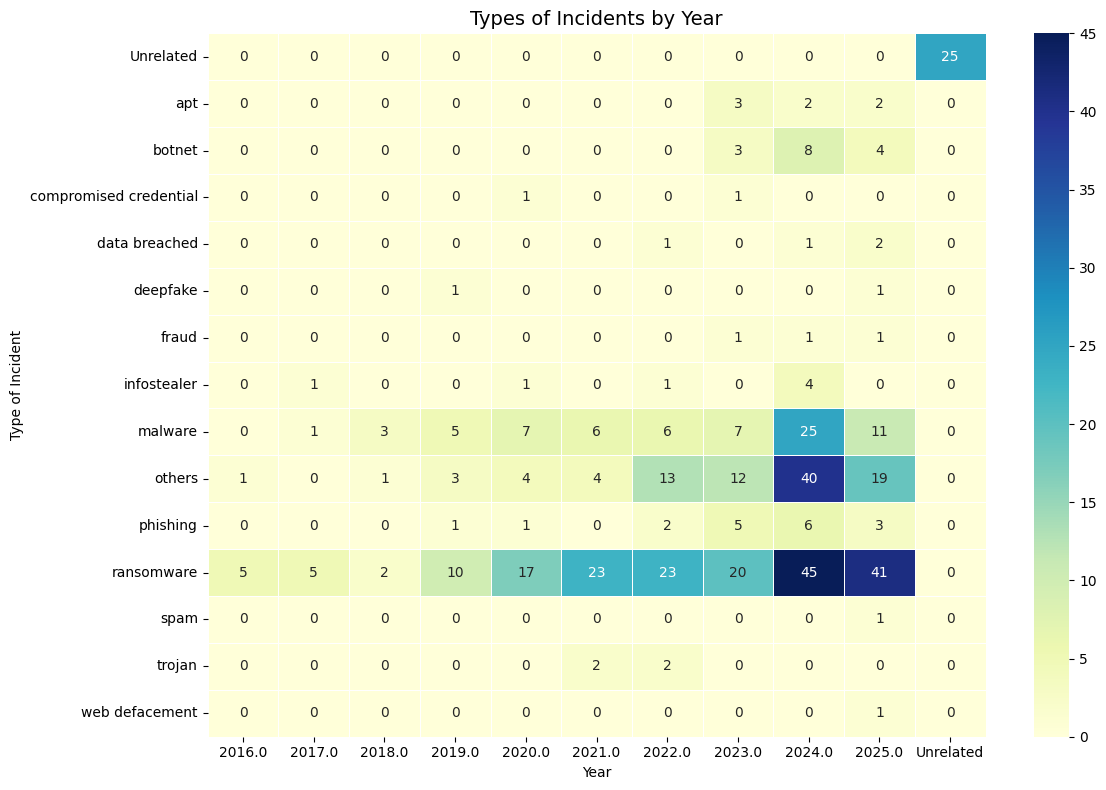

In [ ]:
# Create crosstab directly (TYPE OF INCIDENT by Year)
heatmap_data = pd.crosstab(df2['TYPE OF INCIDENT'], df2['Year'])

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5)

plt.title("Types of Incidents by Year", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Type of Incident")
plt.tight_layout()
plt.show()


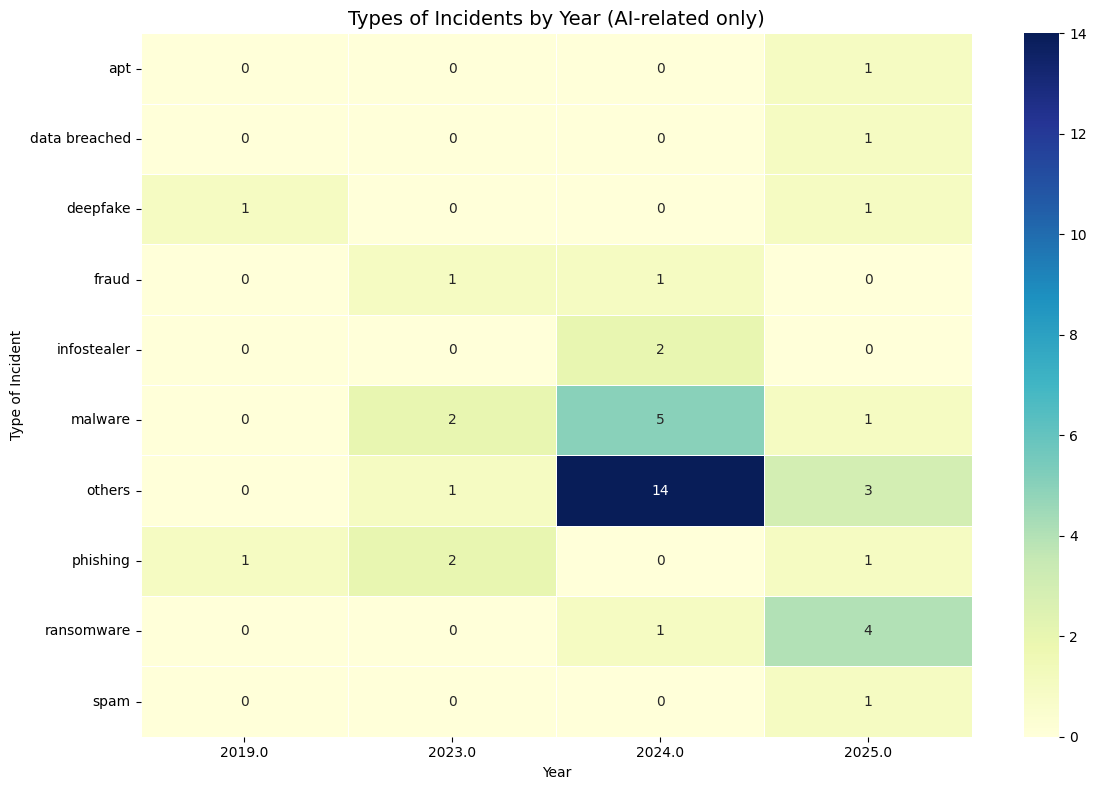

In [ ]:
# Filter only AI-related incidents
df_ai = df2[df2['AI CYBERATTACK'] == 'yes']

# Create pivot table for AI-related incidents
pivot_ai = df_ai.pivot_table(
    index='TYPE OF INCIDENT',
    columns='Year',
    values='TITLE',
    aggfunc='count',
    fill_value=0
)

# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_ai, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5)

plt.title("Types of Incidents by Year (AI-related only)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Type of Incident")
plt.tight_layout()
plt.show()


In [ ]:
# Make sure DATE_PARSED is datetime
df2['DATE_PARSED'] = pd.to_datetime(df2['DATE_PARSED'], errors='coerce')

# Drop rows without dates and set index
df_dates = df2.dropna(subset=['DATE_PARSED']).set_index('DATE_PARSED')

# Resample by month (use 'ME' = month end to avoid FutureWarning)
monthly = df_dates.resample('ME').size().reset_index(name='count')

# Plot timeline
fig = px.line(monthly, x='DATE_PARSED', y='count', title='Monthly Incident Count (All)')
fig.update_xaxes(rangeslider_visible=True)
fig.show()



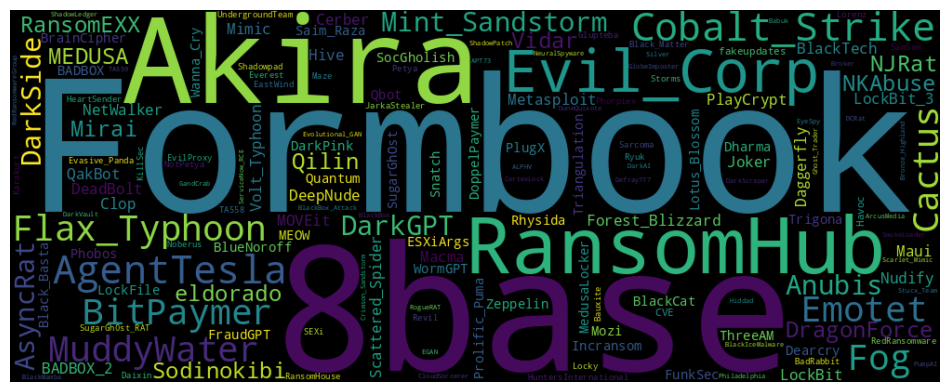

In [ ]:
from wordcloud import WordCloud
ta_freq = df2['THREAT ACTOR'].dropna().value_counts().to_dict()
text = " ".join([ (name + " ") * int(cnt) for name, cnt in ta_freq.items() if name != 'Unrelated' ])
wc = WordCloud(width=1000, height=400, collocations=False).generate(text)
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()